# Feature processing and selection

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo


from scipy.stats import gaussian_kde    # We use this to plot kernel density

In [138]:
# 880 is the ID for the Support2 data.
support2 = fetch_ucirepo(id=880)

# Load the entire dataset into a pandas dataframe
# support2.data.features does not include some variables that we are interested
df = support2.data.original
display(df.head(n=2))

# Summary print outs
print(50*"+-")
print("Online data dictionary")
print("https://archive.ics.uci.edu/dataset/880/support2")

print(50*"+-")
print("Column names:\n", df.columns)

print(50*"+-")
print("Shape of the data: ", df.shape)

print(50*"+-")
print("'slos' column contains NA or null?")
print(df.slos.isna().any() == 1)


,id,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
0,1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0
1,2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0


+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
Online data dictionary
https://archive.ics.uci.edu/dataset/880/support2
+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
Column names:
 Index(['id', 'age', 'death', 'sex', 'hospdead', 'slos', 'd.time', 'dzgroup',
       'dzclass', 'num.co', 'edu', 'income', 'scoma', 'charges', 'totcst',
       'totmcst', 'avtisst', 'race', 'sps', 'aps', 'surv2m', 'surv6m', 'hday',
       'diabetes', 'dementia', 'ca', 'prg2m', 'prg6m', 'dnr', 'dnrday',
       'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea',
       'sod', 'ph', 'glucose', 'bun', 'urine', 'adlp', 'adls', 'sfdm2',
       'adlsc'],
      dtype='object')
+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
Shape of the data:  (9105, 48)
+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-

In [139]:
# Limiting the examples to patients passed away while hospitalized
df = df[df.hospdead == 1]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2360 entries, 1 to 9103
Data columns (total 48 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        2360 non-null   int64  
 1   age       2360 non-null   float64
 2   death     2360 non-null   int64  
 3   sex       2360 non-null   object 
 4   hospdead  2360 non-null   int64  
 5   slos      2360 non-null   int64  
 6   d.time    2360 non-null   int64  
 7   dzgroup   2360 non-null   object 
 8   dzclass   2360 non-null   object 
 9   num.co    2360 non-null   int64  
 10  edu       1747 non-null   float64
 11  income    1465 non-null   object 
 12  scoma     2359 non-null   float64
 13  charges   2299 non-null   float64
 14  totcst    2084 non-null   float64
 15  totmcst   1317 non-null   float64
 16  avtisst   2353 non-null   float64
 17  race      2341 non-null   object 
 18  sps       2359 non-null   float64
 19  aps       2359 non-null   float64
 20  surv2m    2359 non-null   float64
 

In [140]:
# Now that we selected patients 
# Check that the value of "death" and "hospdead" is uniformly "1".
print(50*"+-")
print("'death' and 'hospdeath' columns are all '1's?")
print(df.death.unique().all() == 1 and df.hospdead.unique().all() == 1)

# Drop columns that are now constant or irrelevant
df.drop(columns=["death", "hospdead", "id", "d.time", 
                 "dzclass", "charges", "totcst", "totmcst", 
                 "prg2m", "prg6m", "dnrday", "adlp", 
                 "adls", "meanbp", "avtisst"], inplace=True)



+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
'death' and 'hospdeath' columns are all '1's?
True


/tmp/ipykernel_1985/651423432.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["death", "hospdead", "id", "d.time",


## Feature engineering

In [141]:
# Missing value in features ["sps", "aps", "surv2m", "surv6m"]. 
# It turns out there is exactly one missing value for all these four features.

cols = ["sps", "aps", "surv2m", "surv6m", "scoma"]
df["sps_aps_surv_missing"] = df[cols].isna().any(axis=1).astype(int)
df[cols]

impute_values = {
    "sps": df["sps"].mean(),       #  
    "aps": df["aps"].mean(),
    "surv2m": df["surv2m"].mean(),
    "surv6m": df["surv6m"].mean(),
    "scoma": df["scoma"].mean()
}

df[cols] = df[cols].fillna(impute_values)


df["dnr"] = df["dnr"].fillna("missing")
df["income"] = df["income"].fillna("missing")
df["race"] = df["race"].fillna("missing")
df["sfdm2"] = df["sfdm2"].fillna("missing")

df["wblc"] = df["wblc"].fillna(9) # Using data curator's suggested fill-in value for missing value
df["pafi"] = df["pafi"].fillna(333.3) # Using data curator's suggested fill-in value for missing value
df["alb"] = df["alb"].fillna(3.5) # Using data curator's suggested fill-in value for missing value
df["bili"] = df["bili"].fillna(1.01) # Using data curator's suggested fill-in value for missing value
df["crea"] = df["crea"].fillna(1.01) # Using data curator's suggested fill-in value for missing value
df["bun"] = df["bun"].fillna(6.51) # Using data curator's suggested fill-in value for missing value
df["urine"] = df["urine"].fillna(2502) # Using data curator's suggested fill-in value for missing value

df["ph"] = df["ph"].fillna(df["ph"].median()) # It makes sense to replace missing ph with sample median
df["glucose"] = df["glucose"].fillna(df["glucose"].median()) # It makes sense to replace missing ph with sample median

df["resp"] = df["resp"].replace(0, np.nan)
df["resp"] = df["resp"].fillna(df["resp"].median()) # It doesn't make sense to have 0 resperation rate!

df["hrt"] = df["hrt"].replace([0, 1], np.nan)
df["hrt"] = df["hrt"].fillna(df["hrt"].median()) # It doesn't make sense to have 0 heart rate!


/tmp/ipykernel_1985/1658358155.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sps_aps_surv_missing"] = df[cols].isna().any(axis=1).astype(int)
/tmp/ipykernel_1985/1658358155.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[cols] = df[cols].fillna(impute_values)
/tmp/ipykernel_1985/1658358155.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://p

In [142]:
# Define a function that turns education years into bins including 'missing'
def edu_bins(edu):
    if pd.isna(edu):
        return "missing"
    elif edu < 12:
        return "pre_hs" # did not complete highschool 
    elif edu == 12:
        return "hs"
    elif edu < 16:
        return "some_college"
    else:
        return "college_or_higher"

df["edu_bins"] = df.edu.apply(edu_bins)
df["edu_bins"]
df.drop(columns=["edu"], inplace=True)



/tmp/ipykernel_1985/2521654381.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["edu_bins"] = df.edu.apply(edu_bins)
/tmp/ipykernel_1985/2521654381.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["edu"], inplace=True)


## Place holder

In [143]:
feat = "sfdm2"
df[feat].describe()

count                 2360
unique                   6
top       <2 mo. follow-up
freq                  2261
Name: sfdm2, dtype: object

In [144]:
# Median-based binary
slos_median = df["slos"].median()
df["slos_bin_median"] = (df["slos"] > slos_median).astype(int)

# 30-day binary
df["slos_bin_30"] = (df["slos"] > 30).astype(int)

# 3-class: [0–7], (7–30], (30+]
def slos_3class(x):
    if x <= 7:
        return 0
    elif x <= 30:
        return 1
    else:
        return 2

df["slos_3class_7_30"] = df["slos"].apply(slos_3class)

# 5-class: [0–7], (7–30], (30–60], (60–180], (180+]
def slos_5class_fixed(x):
    if x <= 7:
        return 0
    elif x <= 30:
        return 1
    elif x <= 60:
        return 2
    elif x <= 180:
        return 3
    else:
        return 4

df["slos_5class_fixed"] = df["slos"].apply(slos_5class_fixed)

# 5-class: quintiles (equal-sized bins)
df["slos_5class_quantile"] = pd.qcut(df["slos"], q=5, labels=False)


/tmp/ipykernel_1985/402101551.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["slos_bin_median"] = (df["slos"] > slos_median).astype(int)
/tmp/ipykernel_1985/402101551.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["slos_bin_30"] = (df["slos"] > 30).astype(int)
/tmp/ipykernel_1985/402101551.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pan

In [145]:
df.columns

Index(['age', 'sex', 'slos', 'dzgroup', 'num.co', 'income', 'scoma', 'race',
       'sps', 'aps', 'surv2m', 'surv6m', 'hday', 'diabetes', 'dementia', 'ca',
       'dnr', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea',
       'sod', 'ph', 'glucose', 'bun', 'urine', 'sfdm2', 'adlsc',
       'sps_aps_surv_missing', 'edu_bins', 'slos_bin_median', 'slos_bin_30',
       'slos_3class_7_30', 'slos_5class_fixed', 'slos_5class_quantile'],
      dtype='object')

In [146]:
def select_outcome(df, outcome_col):
    """
    Returns X, y after dropping all other outcome columns and 'slos'.
    """
    outcome_cols = [
        "slos", "slos_bin_median", "slos_bin_30",
        "slos_3class_7_30", "slos_5class_fixed", "slos_5class_quantile"
    ]
    X = df.drop(columns=[col for col in outcome_cols if col != outcome_col])
    y = df[outcome_col]
    return X.drop(columns=[outcome_col]), y


In [147]:
X, y = select_outcome(df, "slos_bin_median")

In [148]:
X.columns

Index(['age', 'sex', 'dzgroup', 'num.co', 'income', 'scoma', 'race', 'sps',
       'aps', 'surv2m', 'surv6m', 'hday', 'diabetes', 'dementia', 'ca', 'dnr',
       'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod',
       'ph', 'glucose', 'bun', 'urine', 'sfdm2', 'adlsc',
       'sps_aps_surv_missing', 'edu_bins'],
      dtype='object')

count    2360.000000
mean       27.870708
std        34.827958
min         0.000000
25%         0.000000
50%         9.000000
75%        44.000000
max       100.000000
Name: scoma, dtype: float64

No missing value


(array([1086.,  202.,    0.,    0.,    0.,  173.,    0.,  113.,  298.,
           0.,    0.,   59.,   78.,    0.,    0.,    0.,    0.,   36.,
          43.,  272.]),
 array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
         55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100.]),
 <BarContainer object of 20 artists>)

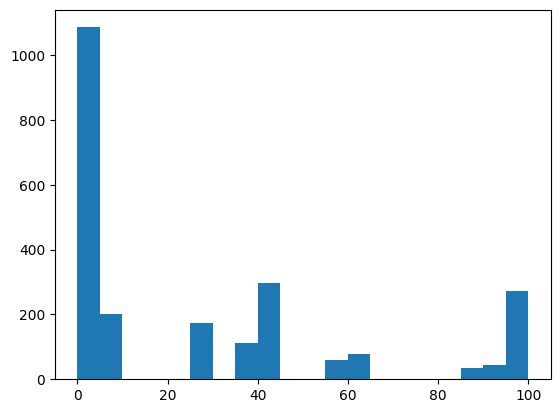

In [109]:
feat = "scoma"
display(df[feat].describe())
try:
    display(df[df[feat].isna()].index[0])

except IndexError: 
    print("No missing value")

#df[5393]
#df.loc[df[df["sps"].isna()].index[0]].slos
plt.hist(df[feat],bins=20)